In [3]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

import numpy as np

In [77]:
q = QuantumRegister(3, "q")
a = QuantumRegister(2, "a")
c = ClassicalRegister(3, "c")
qc = QuantumCircuit(q, a, c)

In [78]:
qc.ry(np.pi/3, q[0])
qc.barrier()

qc.cx(q[0], q[1])
qc.cx(q[0], q[2])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <Qubit register=(2, "a"), index=0>, <Qubit register=(2, "a"), index=1>), clbits=())

In [79]:
qc.h(q)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <Qubit register=(2, "a"), index=0>, <Qubit register=(2, "a"), index=1>), clbits=())

In [80]:
qc.z(q[1])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <Qubit register=(2, "a"), index=0>, <Qubit register=(2, "a"), index=1>), clbits=())

In [81]:
qc.h(q)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <Qubit register=(2, "a"), index=0>, <Qubit register=(2, "a"), index=1>), clbits=())

In [82]:
qc.cx(q[0], a[0])
qc.cx(q[1], a[0])
qc.cx(q[1], a[1])
qc.cx(q[2], a[1])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <Qubit register=(2, "a"), index=0>, <Qubit register=(2, "a"), index=1>), clbits=())

In [83]:
qc.x(a[1])
qc.ccx(a[0], a[1], q[0])
qc.x(a[1])

qc.ccx(a[0], a[1], q[1])

qc.x(a[0])
qc.ccx(a[0], a[1], q[2])
qc.x(a[0])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <Qubit register=(2, "a"), index=0>, <Qubit register=(2, "a"), index=1>), clbits=())

/Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/styles/default.json, ~/default.json, ~/.qiskit/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


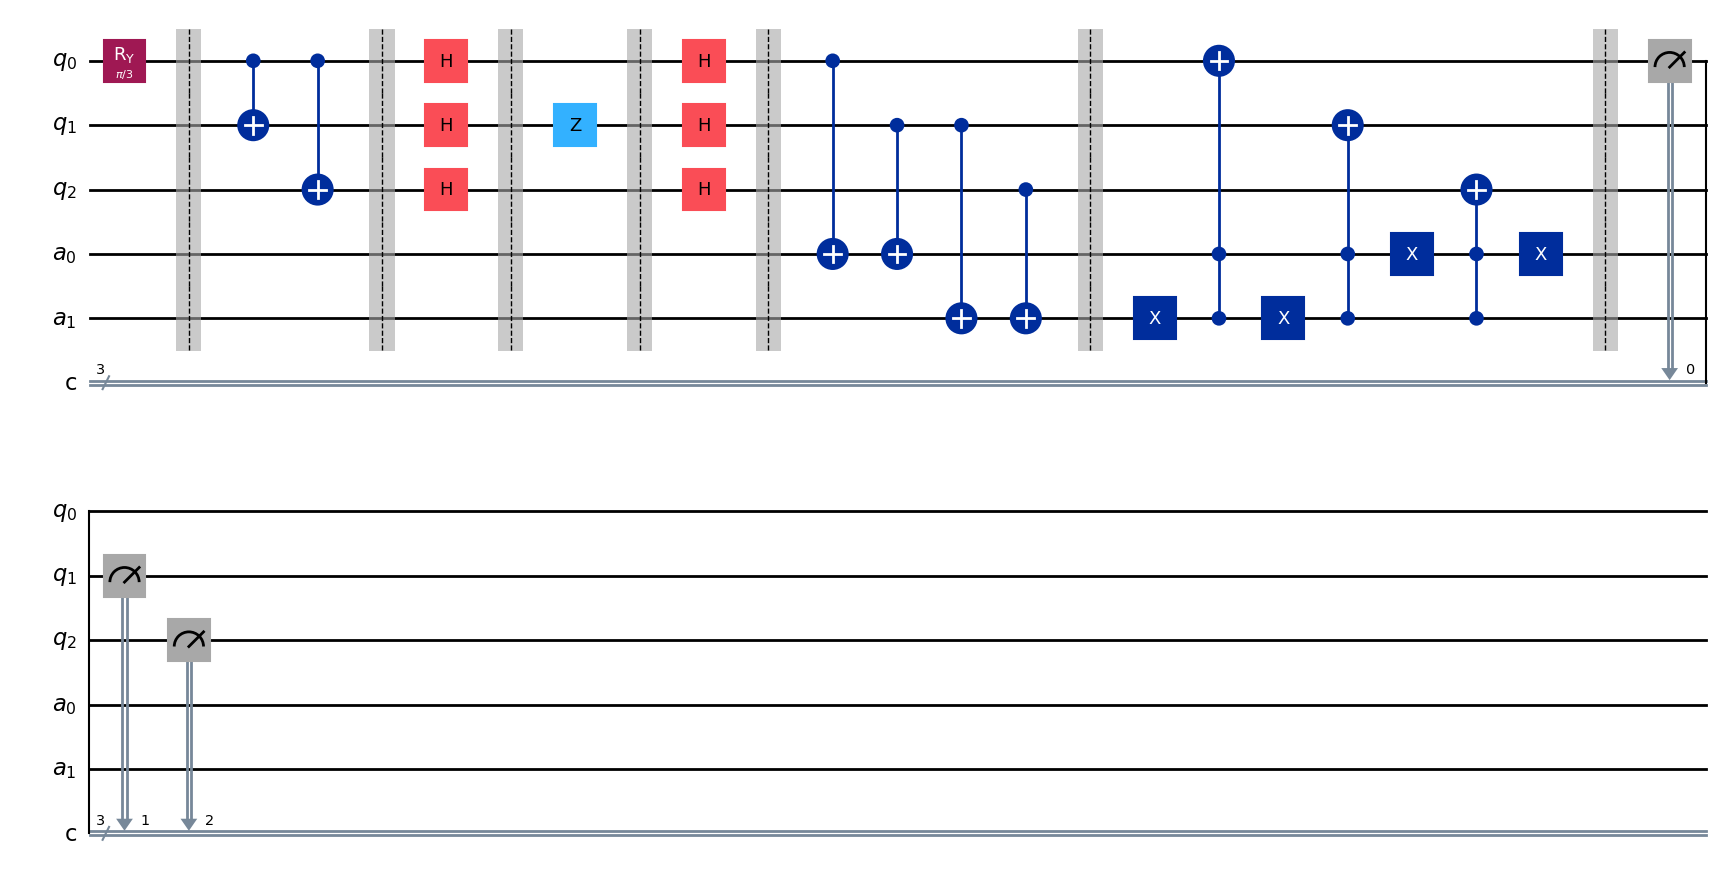

In [84]:
qc.measure(q, c)
qc.draw(output='mpl')

In [38]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=8)

In [85]:
pm = generate_preset_pass_manager(backend=backend)
isa_qc = pm.run(qc)
sampler = Sampler(mode=backend)
result = sampler.run([isa_qc]).result()
result

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=4096, num_bits=3>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-03-14 21:35:35', stop='2026-03-14 21:35:37', size=4096>)])}, 'version': 2})

In [86]:
data = result[0].data
data

DataBin(c=BitArray(<shape=(), num_shots=4096, num_bits=3>))

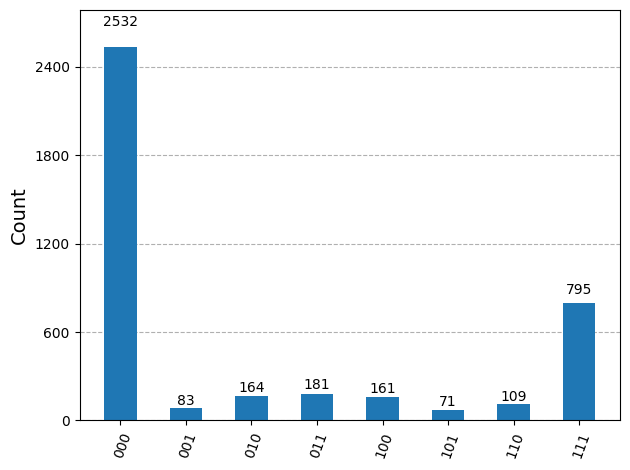

In [87]:
plot_histogram(data['c'].get_counts())